In [1]:
import yfinance as yf

ticker = "GC=F"

gold_data = yf.download(ticker, start="2010-01-01", end=None, progress=False)

YF.download() has changed argument auto_adjust default to True


In [2]:
gold_data.reset_index(inplace=True)

In [3]:
gold_data["Pct_Change"] = gold_data["Close"].pct_change()

In [4]:
gold_data

Price,Date,Close,High,Low,Open,Volume,Pct_Change
Ticker,,GC=F,GC=F,GC=F,GC=F,GC=F,
0,2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184,NaN
1,2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53,0.000358
2,2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363,0.015920
3,2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56,-0.002465
4,2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54,0.004501
...,...,...,...,...,...,...,...
3840,2025-04-11,3222.199951,3235.000000,3182.100098,3182.100098,862,0.021235
3841,2025-04-14,3204.800049,3228.800049,3194.500000,3215.500000,263,-0.005400
3842,2025-04-15,3218.699951,3218.699951,3214.000000,3216.000000,390,0.004337


In [5]:
gold_data = gold_data[1:]

In [6]:
gold_data["Pct_Change"] *= 100

/tmp/ipykernel_8979/1091266023.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gold_data["Pct_Change"] *= 100


In [7]:
gold_data.columns

MultiIndex([(      'Date',     ''),
            (     'Close', 'GC=F'),
            (      'High', 'GC=F'),
            (       'Low', 'GC=F'),
            (      'Open', 'GC=F'),
            (    'Volume', 'GC=F'),
            ('Pct_Change',     '')],
           names=['Price', 'Ticker'])

In [8]:
gold_data

Price,Date,Close,High,Low,Open,Volume,Pct_Change
Ticker,,GC=F,GC=F,GC=F,GC=F,GC=F,
1,2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53,0.035790
2,2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363,1.591991
3,2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56,-0.246505
4,2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54,0.450091
5,2010-01-11,1150.699951,1161.199951,1143.000000,1150.699951,177,1.098225
...,...,...,...,...,...,...,...
3840,2025-04-11,3222.199951,3235.000000,3182.100098,3182.100098,862,2.123479
3841,2025-04-14,3204.800049,3228.800049,3194.500000,3215.500000,263,-0.540001
3842,2025-04-15,3218.699951,3218.699951,3214.000000,3216.000000,390,0.433721


In [9]:
import pandas as pd
import datetime as dt
from datetime import date
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import tensorflow as tf

2025-04-19 16:31:18.576053: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745094678.618968    8979 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745094678.630505    8979 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745094678.661173    8979 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745094678.661214    8979 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745094678.661218    8979 computation_placer.cc:177] computation placer alr

In [10]:
gold_data[gold_data["Date"].isna() == True]

Price,Date,Close,High,Low,Open,Volume,Pct_Change
Ticker,,GC=F,GC=F,GC=F,GC=F,GC=F,


In [12]:
gold_data

Price,Date,Close,High,Low,Open,Volume,Pct_Change
Ticker,,GC=F,GC=F,GC=F,GC=F,GC=F,
1,2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53,0.035790
2,2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363,1.591991
3,2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56,-0.246505
4,2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54,0.450091
5,2010-01-11,1150.699951,1161.199951,1143.000000,1150.699951,177,1.098225
...,...,...,...,...,...,...,...
3840,2025-04-11,3222.199951,3235.000000,3182.100098,3182.100098,862,2.123479
3841,2025-04-14,3204.800049,3228.800049,3194.500000,3215.500000,263,-0.540001
3842,2025-04-15,3218.699951,3218.699951,3214.000000,3216.000000,390,0.433721


In [16]:
# Flatten the MultiIndex columns
gold_data.columns = [col[0] for col in gold_data.columns]

In [18]:
from sklearn.preprocessing import StandardScaler

gold_data["Date"] = pd.to_datetime(gold_data["Date"])

# Drop rows with missing % Change
gold_data = gold_data.dropna(subset=["Pct_Change"])

# Define features
features = ["Close", "High", "Low", "Open", "Volume"]
target = "Pct_Change"

# Normalize features
scaler = StandardScaler()
gold_data[features] = scaler.fit_transform(gold_data[features])

/tmp/ipykernel_8979/852348330.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gold_data["Date"] = pd.to_datetime(gold_data["Date"])


In [24]:
from torch.utils.data import Dataset

SEQ_LEN = 10


class GoldLSTMDataset(Dataset):
    def __init__(self, df, seq_len):
        self.X, self.y = [], []
        data = df[features + [target]].values
        for i in range(len(data) - seq_len):
            self.X.append(data[i : i + seq_len, :-1])  # features
            self.y.append(data[i + seq_len, -1])  # next day's % change
        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [26]:
import torch
from torch.utils.data import DataLoader

# Train/test split by time (no shuffle)
split_idx = int(len(gold_data) * 0.8)

train_df = gold_data.iloc[:split_idx]
test_df = gold_data.iloc[split_idx - SEQ_LEN :]  # keep overlap for continuity

train_dataset = GoldLSTMDataset(train_df, SEQ_LEN)
test_dataset = GoldLSTMDataset(test_df, SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

/tmp/ipykernel_8979/3072075687.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  self.X = torch.tensor(self.X, dtype=torch.float32)


In [28]:
import torch.nn as nn


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # take the output from the last time step

In [29]:
model = LSTMModel(input_size=len(features), hidden_size=64, num_layers=2)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [30]:
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1} | Train Loss: {epoch_loss / len(train_loader):.4f}")

Epoch 1 | Train Loss: 1.0571
Epoch 2 | Train Loss: 1.0549
Epoch 3 | Train Loss: 1.0540
Epoch 4 | Train Loss: 1.0537
Epoch 5 | Train Loss: 1.0534
Epoch 6 | Train Loss: 1.0532
Epoch 7 | Train Loss: 1.0530
Epoch 8 | Train Loss: 1.0528
Epoch 9 | Train Loss: 1.0526
Epoch 10 | Train Loss: 1.0523
Epoch 11 | Train Loss: 1.0521
Epoch 12 | Train Loss: 1.0518
Epoch 13 | Train Loss: 1.0516
Epoch 14 | Train Loss: 1.0513
Epoch 15 | Train Loss: 1.0510
Epoch 16 | Train Loss: 1.0508
Epoch 17 | Train Loss: 1.0505
Epoch 18 | Train Loss: 1.0509
Epoch 19 | Train Loss: 1.0497
Epoch 20 | Train Loss: 1.0512


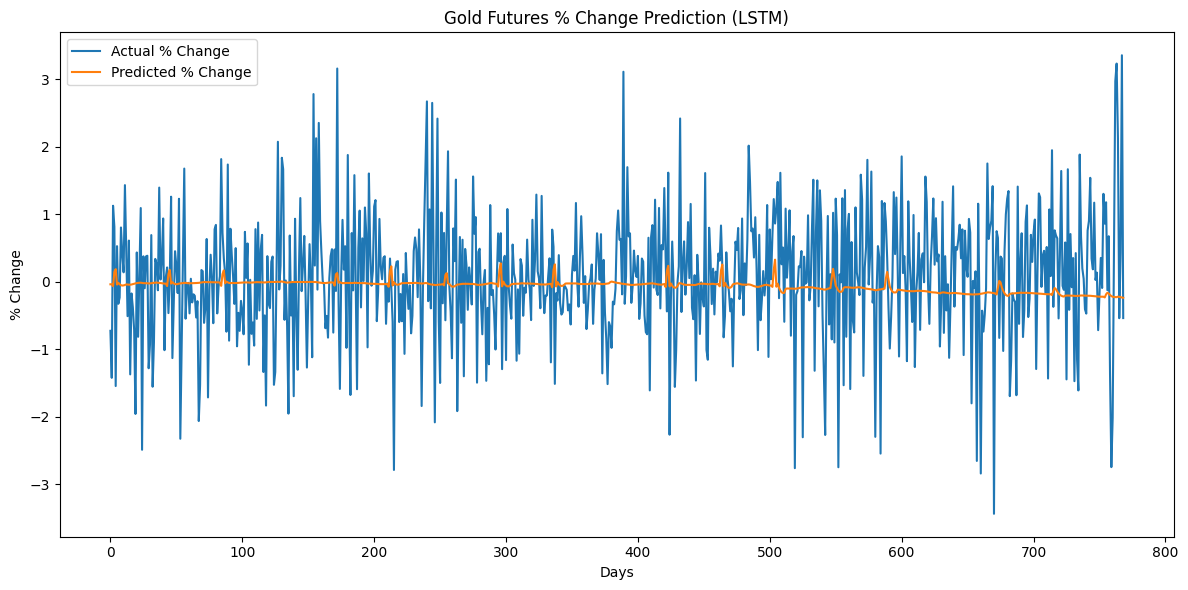

In [32]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch)
        y_true.extend(y_batch.view(-1).tolist())  # Ensure y_batch is flattened
        y_pred.extend(preds.view(-1).tolist())  # Ensure preds is flattened

plt.figure(figsize=(12, 6))
plt.plot(y_true, label="Actual % Change")
plt.plot(y_pred, label="Predicted % Change")
plt.title("Gold Futures % Change Prediction (LSTM)")
plt.xlabel("Days")
plt.ylabel("% Change")
plt.legend()
plt.tight_layout()
plt.show()